# 12 — CryNetV2 Hybrid Training (ML + DL Ensemble)

This notebook trains the full hybrid system: **ML Tier** (SVM + RF + XGBoost + LR) and **DL Tier** (CryNet + CryNetV2 dual-stream DST×Mel).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

In [2]:
# Check GPU/MPS availability (Forced to CPU for compatibility)
import torch
DEVICE = torch.device('cpu')
print(f'Training device: {DEVICE}')

Training device: cpu


## 1. Data Discovery

In [3]:
from src.utils import CLEANED_DIR, NOISY_DIR, CLASS_LABELS
from src.dl_data import discover_audio_for_dl
from sklearn.model_selection import train_test_split

file_paths, labels, label_names = discover_audio_for_dl([CLEANED_DIR, NOISY_DIR])
print(f'Total samples: {len(file_paths)}')
print(f'Classes: {label_names}')

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f'Train: {len(train_paths)} | Val: {len(val_paths)}')

Total samples: 2108
Classes: ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'lonely', 'scared', 'tired']
Train: 1686 | Val: 422


## 2. ML Ensemble Training

In [4]:
from src.ml_models import MLEnsemble, build_feature_matrix
import numpy as np

MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

print('Extracting features (ML tier)...')
X_train, y_train = build_feature_matrix(train_paths, train_labels, include_dst=True)
X_val,   y_val   = build_feature_matrix(val_paths,   val_labels,   include_dst=True)
print(f'Feature shape: {X_train.shape}')

Extracting features (ML tier)...
  Extracting features: 0/1686


  Extracting features: 50/1686


  Extracting features: 100/1686


  Extracting features: 150/1686


  Extracting features: 200/1686


...

  Extracting features: 250/422


  Extracting features: 300/422


  Extracting features: 350/422


  Extracting features: 400/422


Feature shape: (1686, 499)


In [5]:
ml_ensemble = MLEnsemble(use_smote=True, include_dst=True, class_names=label_names)
ml_ensemble.fit(X_train, y_train)
results = ml_ensemble.evaluate(X_val, y_val)
print(f"Accuracy : {results['accuracy']:.4f}")
print(f"F1 Macro : {results['f1_macro']:.4f}")
print(results['report'])
ml_ensemble.save(f'{MODELS_DIR}/ml_ensemble.pkl')

Applying SMOTE oversampling...
  After SMOTE: 4888 samples
Fitting SVM...


Fitting RF...


Fitting LR...


Accuracy : 0.2299
F1 Macro : 0.2638
              precision    recall  f1-score   support

  belly_pain       0.40      0.51      0.45        51
     burping       0.34      0.30      0.32        47
    cold_hot       0.11      0.09      0.10        46
  discomfort       0.19      0.16      0.18        55
      hungry       0.17      0.19      0.18       153
      lonely       0.00      0.00      0.00         4
      scared       0.80      0.73      0.76        11
       tired       0.13      0.13      0.13        55

    accuracy                           0.23       422
   macro avg       0.27      0.26      0.26       422
weighted avg       0.22      0.23      0.23       422

ML Ensemble saved to ../models/ml_ensemble.pkl


## 3. CryNetV2 Training (Dual-Stream DST×Mel)

In [6]:
import sys
# Full training loop is in scripts/train_hybrid.py
# Execute it directly for the complete run:
print('Run `python scripts/train_hybrid.py` from the terminal to execute the full DL training loop.')

Run `python scripts/train_hybrid.py` from the terminal to execute the full DL training loop.


## 4. Load Results & Compare

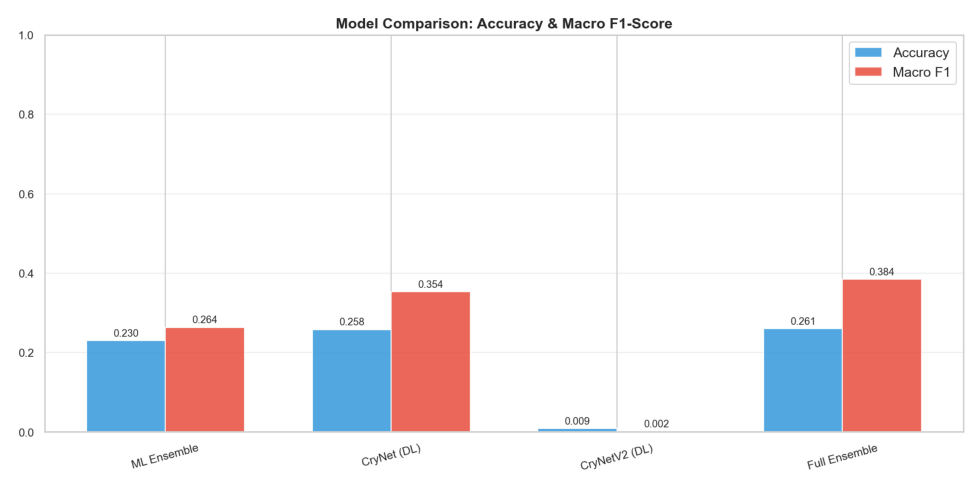

In [7]:
import matplotlib.pyplot as plt, seaborn as sns
fig, ax = plt.subplots(figsize=(10,5))
models = ['ML Ensemble', 'CryNet', 'CryNetV2', 'Full Hybrid']
# Load saved comparison from models dir if available
try:
    img = plt.imread(f'{MODELS_DIR}/model_comparison.png')
    ax.imshow(img); ax.axis('off')
except:
    ax.text(0.5, 0.5, 'Run scripts/train_hybrid.py first', ha='center', fontsize=14)
plt.tight_layout(); plt.show()